# Batch GPQR (Center-Gap)

In [ ]:
%config InlineBackend.figure_formats = ["svg"]

In [ ]:
import torch
from torch.distributions import Normal
from gpytorch.variational import CholeskyVariationalDistribution
from gpytorch.variational import UnwhitenedVariationalStrategy
from gpytorch.means import ConstantMean, Mean
from gpytorch.kernels import RBFKernel, ScaleKernel
from gpytorch.mlls import VariationalELBO
import matplotlib.pyplot as plt

from gpytorch_qr.gpqr_cg import (
    BatchCenterGapQuantileGP,
    BatchCenterGapALDLikelihood,
)

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data preparation

In [ ]:
def mean(x):
    return torch.cos(x * 2 * 3.14)


def std(x):
    return x + 0.1


x = torch.linspace(0, 1, 100).reshape(-1, 1).to(device)
y = (mean(x) + torch.randn(x.shape, device=device).mul(std(x))).squeeze()
q = torch.linspace(0.1, 0.9, 9).to(device)
true_quantiles = mean(x) + std(x) * Normal(0, 1).icdf(q)
x_pred = torch.linspace(0, 1.5, 100).reshape(-1, 1).to(device)

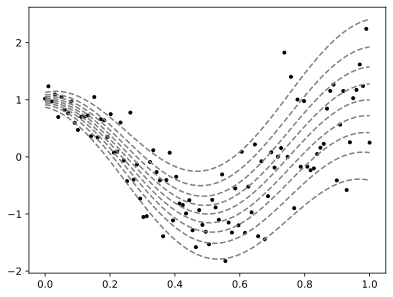

In [ ]:
plt.scatter(x.cpu(), y.cpu(), c="k", marker=".")
plt.plot(x.cpu(), true_quantiles.cpu(), "--", c="gray")
plt.show()

## Prior mean

In [ ]:
class PriorMean(Mean):
    def forward(self, x):
        return mean(x).squeeze()


prior_mean = PriorMean().to(device)

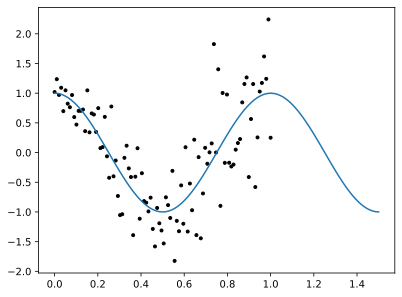

In [ ]:
plt.scatter(x.cpu(), y.cpu(), c="k", marker=".")
plt.plot(x_pred.cpu(), prior_mean(x_pred).detach().cpu())
plt.show()

## Define models and likelihoods

In [ ]:
central_q_index = 2

In [ ]:
class MyGP_ConstantMean(BatchCenterGapQuantileGP):
    def __init__(self, inducing_points, num_quantiles):
        N, D = inducing_points.size()
        variational_distribution = CholeskyVariationalDistribution(
            N,
            batch_shape=torch.Size([num_quantiles]),
        )
        variational_strategy = UnwhitenedVariationalStrategy(
            self,
            inducing_points,
            variational_distribution,
            learn_inducing_locations=True,
        )

        center_mean = ConstantMean()
        gap_mean = ConstantMean(batch_shape=torch.Size([num_quantiles - 1]))
        covar = ScaleKernel(
            RBFKernel(ard_num_dims=D, batch_shape=torch.Size([num_quantiles])),
            batch_shape=torch.Size([num_quantiles]),
        )
        super().__init__(variational_strategy, center_mean, gap_mean, covar)


inducing_points = x.detach().clone()
gp_constantmean = MyGP_ConstantMean(inducing_points, len(q)).to(device)
likelihood_constantmean = BatchCenterGapALDLikelihood(q, central_q_index).to(device)

In [ ]:
class MyGP_PriorMean(BatchCenterGapQuantileGP):
    def __init__(self, inducing_points, num_quantiles):
        N, D = inducing_points.size()
        variational_distribution = CholeskyVariationalDistribution(
            N,
            batch_shape=torch.Size([num_quantiles]),
        )
        variational_strategy = UnwhitenedVariationalStrategy(
            self,
            inducing_points,
            variational_distribution,
            learn_inducing_locations=True,
        )

        center_mean = PriorMean()
        gap_mean = ConstantMean(batch_shape=torch.Size([num_quantiles - 1]))
        covar = ScaleKernel(
            RBFKernel(ard_num_dims=D, batch_shape=torch.Size([num_quantiles])),
            batch_shape=torch.Size([num_quantiles]),
        )
        super().__init__(variational_strategy, center_mean, gap_mean, covar)


inducing_points = x.detach().clone()
gp_priormean = MyGP_PriorMean(inducing_points, len(q)).to(device)
likelihood_priormean = BatchCenterGapALDLikelihood(q, central_q_index).to(device)

## Train

In [ ]:
gp_constantmean.train()
likelihood_constantmean.train()
mll = VariationalELBO(likelihood_constantmean, gp_constantmean, num_data=y.numel())
optimizer = torch.optim.Adam(
    list(gp_constantmean.parameters()) + list(likelihood_constantmean.parameters()),
    lr=0.001,
)

for _ in range(1000):
    output = gp_constantmean(x)
    loss = -mll(output, y).sum()
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

In [ ]:
gp_priormean.train()
likelihood_priormean.train()
mll = VariationalELBO(likelihood_priormean, gp_priormean, num_data=y.numel())
optimizer = torch.optim.Adam(
    list(gp_priormean.parameters()) + list(likelihood_priormean.parameters()),
    lr=0.001,
)

for _ in range(1000):
    output = gp_priormean(x)
    loss = -mll(output, y).sum()
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

## Evaluate

In [ ]:
gp_constantmean.eval()
with torch.no_grad():
    quantiles_constantmean = gp_constantmean.mean_quantiles(
        x_pred, central_q_index
    ).detach()

In [ ]:
gp_priormean.eval()
with torch.no_grad():
    quantiles_priormean = gp_priormean.mean_quantiles(x_pred, central_q_index).detach()

## Plot result

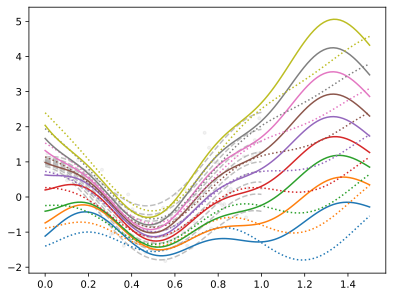

In [ ]:
colors = plt.cm.tab10(range(len(q)))

plt.scatter(x.cpu(), y.cpu(), c="gray", marker=".", alpha=0.1)
plt.plot(x.cpu(), true_quantiles.cpu(), "--", c="gray", alpha=0.5)

for i in range(len(q)):
    plt.plot(x_pred.cpu(), quantiles_constantmean[i].cpu(), ":", color=colors[i])
    plt.plot(x_pred.cpu(), quantiles_priormean[i].cpu(), color=colors[i])

plt.show()